## Exploratory Data Analysis (EDA)
Datasets explored:
- Raw synthetic supplier-commodity dataset
- Preprocessed synthetic supplier-commodity dataset
- Feature engineered synthetic supplier-commodity dataset

### Raw Synthetic Supplier-Commodity Dataset
The initial dataset generated by ChatGPT with the `synthetic_dataset_prompt.txt`

In [1]:
# Nature of dataset
# Check for inconsistencies, class imbalance
# Identify current patterns and relationships
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid", context="talk")
DATA_PATH = Path("../data/raw/syn_supplier_commodity_dataset.csv")
raw_df = pd.read_csv(DATA_PATH)

print(f"Dataset shape: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print(f"Columns: {list(raw_df.columns)}\n")

raw_df.head()

Dataset shape: 20,000 rows x 38 columns
Columns: ['SC_ID', 'Supplier_Name', 'Commodity_Name', 'Year', 'Month', 'Country', 'Region', 'Supplier_Tier', 'Industry_Sector', 'ESG_Score', 'Environmental_Score', 'Social_Score', 'Governance_Score', 'Carbon_Emission_Intensity', 'GHG_Scope1_Intensity', 'GHG_Scope2_Intensity', 'GHG_Scope3_Intensity', 'Water_Intensity', 'Waste_Management_Efficiency', 'Renewable_Energy_Usage', 'Compliance_Level', 'Sustainability_Report_Availability', 'Certifications_Active', 'Lead_Time_Days', 'Production_Capacity', 'On_Time_Delivery_Rate', 'Defect_Rate', 'Incident_History_Count', 'Labour_Compliance_Score', 'Diversity_Index', 'Financial_Stability_Score', 'Freight_Cost', 'Cost_Index', 'Commodity_Price_Index', 'Commodity_Demand', 'Trade_Volume', 'Logistics_Distance_km', 'Risk_Classification']



,SC_ID,Supplier_Name,Commodity_Name,Year,Month,Country,Region,Supplier_Tier,Industry_Sector,ESG_Score,...,Labour_Compliance_Score,Diversity_Index,Financial_Stability_Score,Freight_Cost,Cost_Index,Commodity_Price_Index,Commodity_Demand,Trade_Volume,Logistics_Distance_km,Risk_Classification
0,SC0000001,Pakistan State Oil (PSO),"Refined petroleum products, LPG, lubricants",2019,January,Pakistan,"Middle East, North Africa, Afghanistan and Pak...",1,Oil and Gas,84.92,...,89.41,0.262,62.73,23128.21,1.167,1.040,81557,10190,285,High
1,SC0000002,Thai Union Group,Processed seafood raw materials,2019,January,Thailand,East Asia and Pacific,1,FMCG/Agriculture,70.41,...,98.50,0.338,61.12,13834.64,0.966,0.999,36064,28043,1175,High
2,SC0000003,Twiga Foods,"Fresh produce aggregation (fruits, vegetables)",2019,January,Tanzania,Sub-Saharan Africa,2,Agri Aggregation/Logistics,76.36,...,68.30,0.320,57.99,17980.15,1.511,1.179,58273,1,4198,High
3,SC0000004,Petkim,Petrochemical products,2019,January,Turkey,Europe and Central Asia,1,Petrochemicals,71.25,...,81.87,0.198,92.47,33259.99,0.954,1.088,47418,17522,34,Moderate
4,SC0000005,Chaudhary Group (CG Cement),Cement and building materials,2019,January,Nepal,South Asia,2,Construction Materials,68.91,...,92.30,0.423,70.37,10146.18,0.958,1.021,8282,6824,791,Moderate


In [2]:
# Summary statistics & data types
numeric_summary = raw_df.describe(include=[np.number]).T.round(3)
dtype_summary = (
    raw_df.dtypes.astype(str)
    .reset_index()
    .rename(columns={"index": "column", 0: "dtype"})
)

missing_summary = (
    raw_df.isna()
    .sum()
    .to_frame(name="missing_count")
    .assign(missing_pct=lambda df: (df["missing_count"] / len(raw_df)) * 100)
    .sort_values("missing_pct", ascending=False)
)

print("Numeric feature distribution overview:")
numeric_summary

print("\nColumn dtype summary:")
dtype_summary

print("\nTop missingness signals:")
missing_summary.head(15)

Numeric feature distribution overview:

Column dtype summary:

Top missingness signals:


,missing_count,missing_pct
Certifications_Active,7199,35.995
ESG_Score,199,0.995
Commodity_Name,0,0.000
Year,0,0.000
SC_ID,0,0.000
Supplier_Name,0,0.000
Country,0,0.000
Month,0,0.000
Supplier_Tier,0,0.000
Region,0,0.000


In [3]:
# Identifier uniqueness & categorical inconsistencies
sc_duplicates = raw_df.duplicated(subset=["SC_ID"]).sum()
print(f"Duplicate SC_ID rows: {sc_duplicates}")

region_variants = raw_df["Region"].str.strip().str.lower().value_counts()
country_case_issues = raw_df["Country"].str.contains(r"[a-z]", regex=True).sum()
print("\nPotential inconsistencies:")
print(f"  - Unique Risk_Classification labels: {raw_df['Risk_Classification'].unique()}")
print(f"  - Region label variations (lower-cased):\n{region_variants}\n")
print(f"  - Countries containing lowercase characters (likely need uppercasing): {country_case_issues}")

certificates_split = raw_df["Certifications_Active"].fillna("").str.split(";")
certificate_counts = (
    certificates_split.explode()
    .str.strip()
    .replace({"": np.nan})
    .value_counts()
)
print("Top certifications observed:")
certificate_counts.head(10)


Duplicate SC_ID rows: 0

Potential inconsistencies:
  - Unique Risk_Classification labels: ['High' 'Moderate' 'Low']
  - Region label variations (lower-cased):
Region
sub-saharan africa                                     3435
latin america and caribbean                            3200
east asia and pacific                                  3153
south asia                                             2740
europe and central asia                                2713
middle east, north africa, afghanistan and pakistan    2610
north america                                          2149
Name: count, dtype: int64

  - Countries containing lowercase characters (likely need uppercasing): 19928
Top certifications observed:


Certifications_Active
ISO 9001      3481
BRCGS         2184
Fairtrade     2167
LEED          2155
ISO 14001     2153
FSSC 22000    2127
SA8000        2126
RSPO          2028
Name: count, dtype: int64

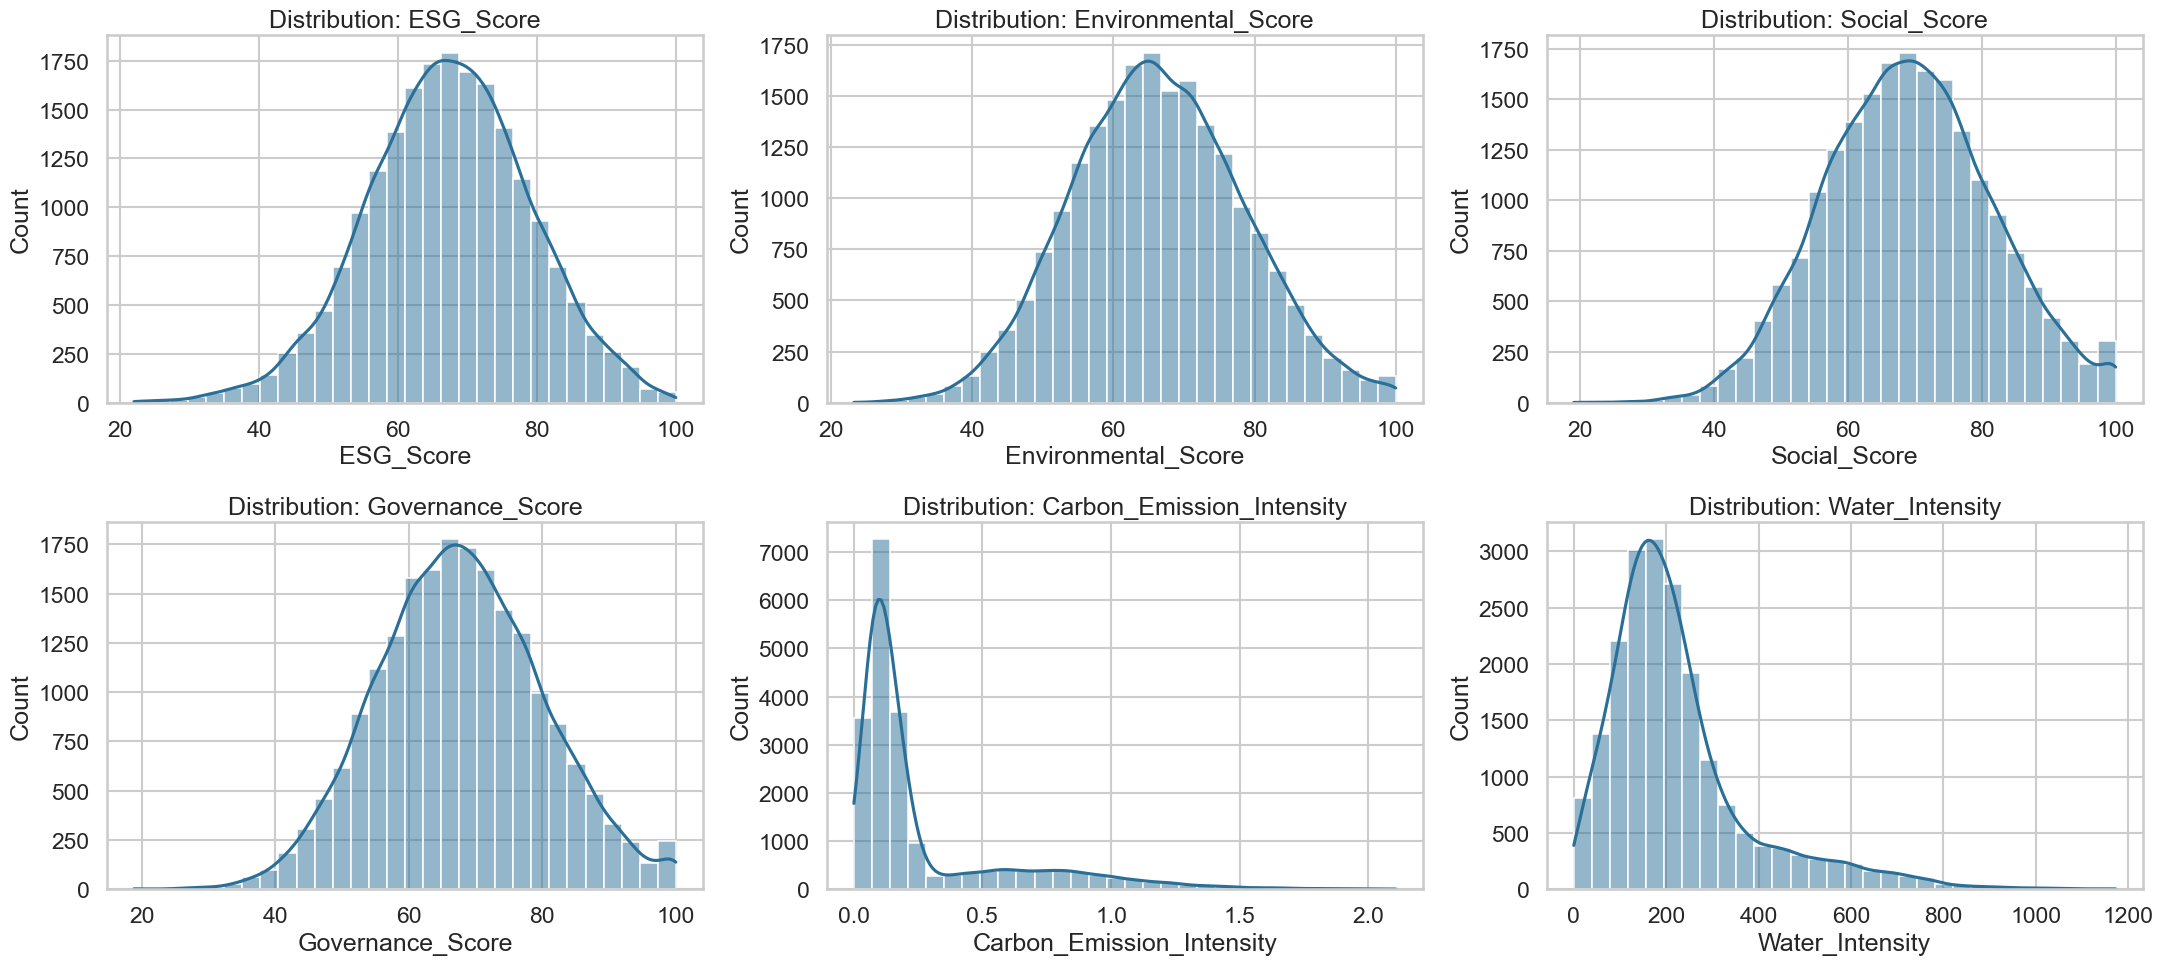

C:\Users\amtan\AppData\Local\Temp\ipykernel_6460\1719668134.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


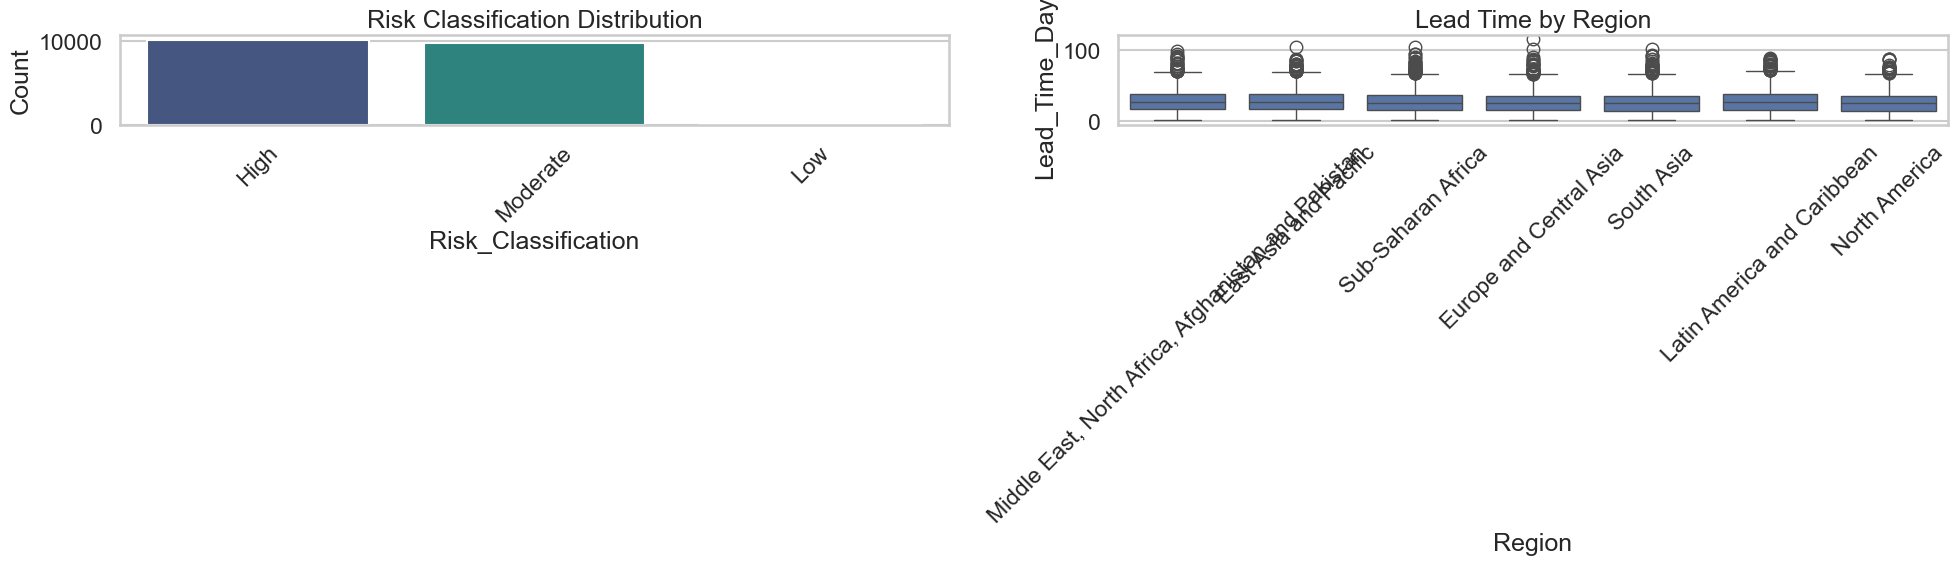

In [4]:
# Distributional analysis
fig, axes = plt.subplots(2, 3, figsize=(22, 10))
score_cols = [
    "ESG_Score",
    "Environmental_Score",
    "Social_Score",
    "Governance_Score",
    "Carbon_Emission_Intensity",
    "Water_Intensity",
]
for ax, col in zip(axes.flat, score_cols):
    sns.histplot(raw_df[col], bins=30, ax=ax, kde=True, color="#2a6f97")
    ax.set_title(f"Distribution: {col}")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
sns.countplot(
    data=raw_df,
    x="Risk_Classification",
    order=raw_df["Risk_Classification"].value_counts().index,
    palette="viridis",
    ax=axes[0],
)
axes[0].set_title("Risk Classification Distribution")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=45)

sns.boxplot(data=raw_df, x="Region", y="Lead_Time_Days", ax=axes[1])
axes[1].set_title("Lead Time by Region")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


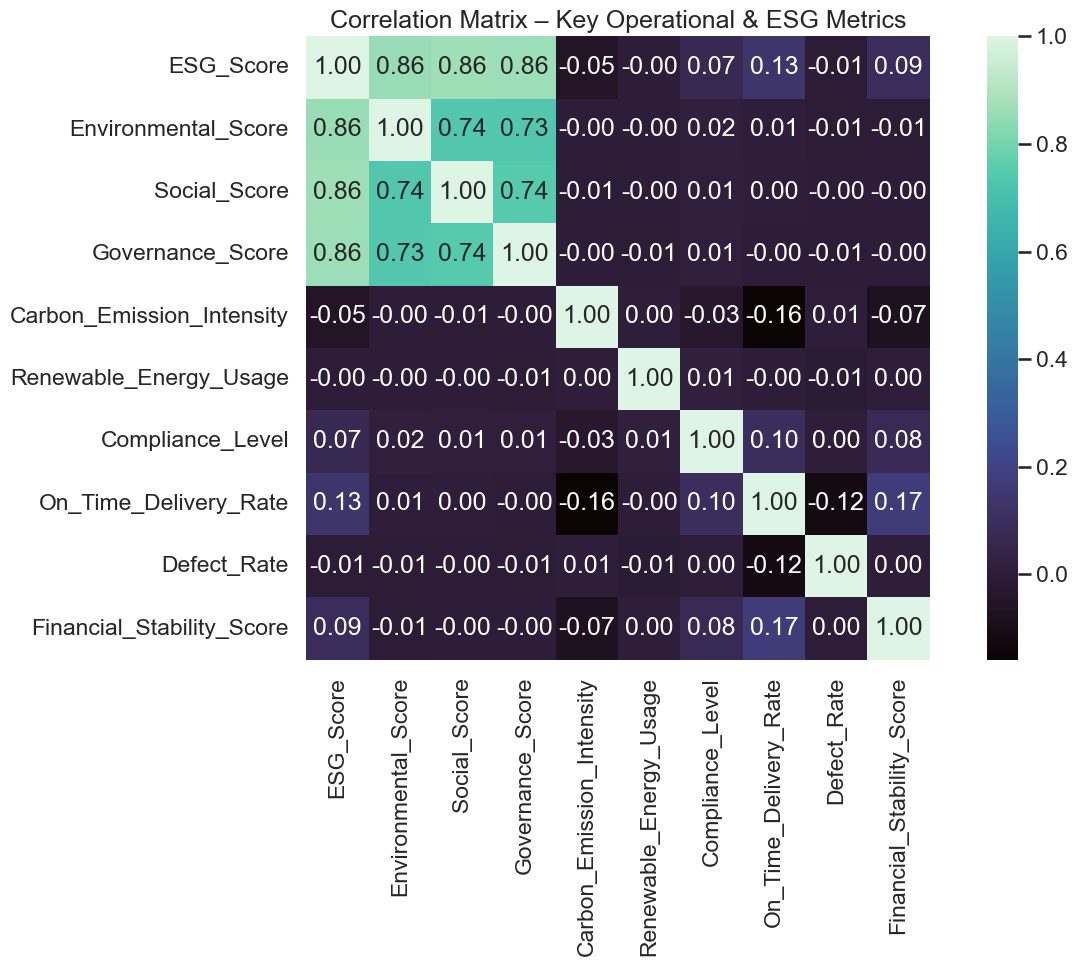

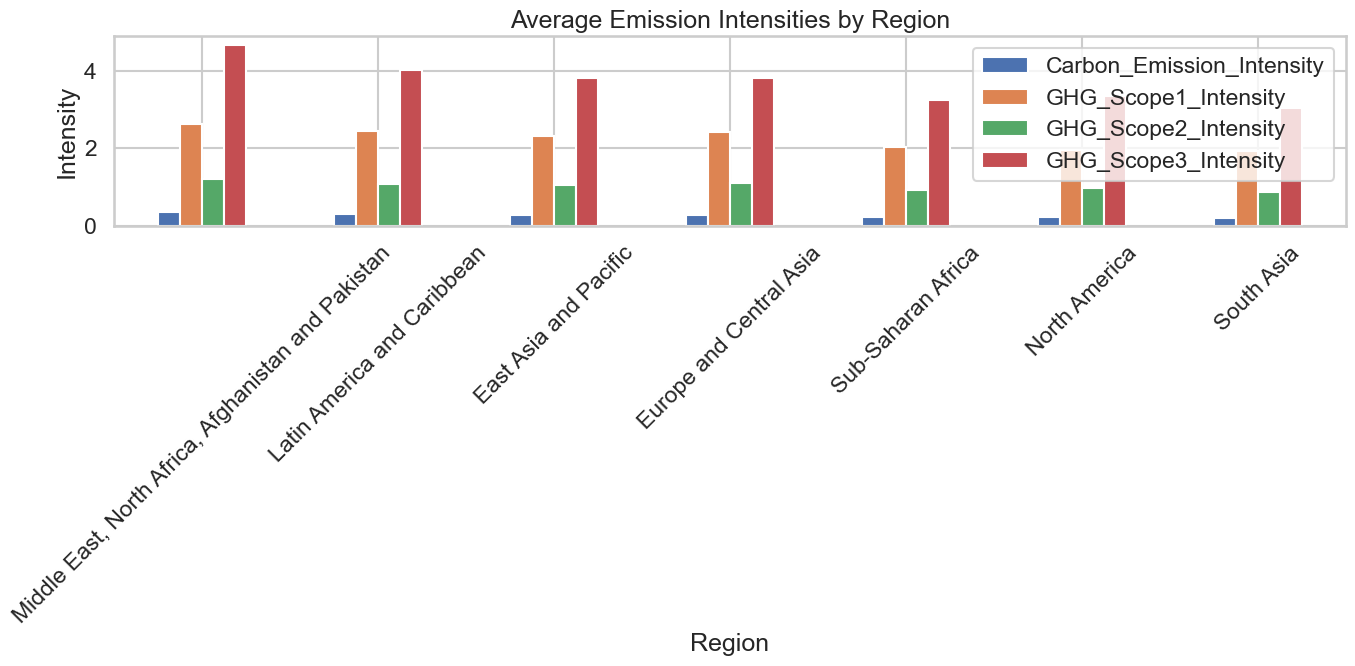

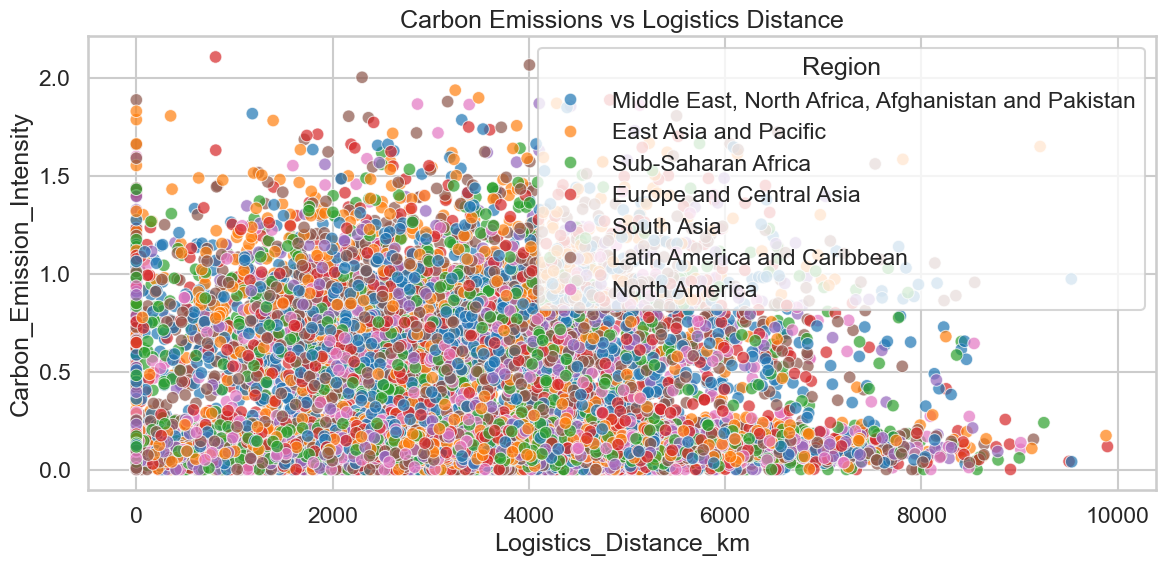

In [5]:
# Relationship analysis
numeric_subset = raw_df[[
    "ESG_Score",
    "Environmental_Score",
    "Social_Score",
    "Governance_Score",
    "Carbon_Emission_Intensity",
    "Renewable_Energy_Usage",
    "Compliance_Level",
    "On_Time_Delivery_Rate",
    "Defect_Rate",
    "Financial_Stability_Score",
]]

corr_matrix = numeric_subset.corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="mako", square=True)
plt.title("Correlation Matrix – Key Operational & ESG Metrics")
plt.tight_layout()
plt.show()

region_metrics = (
    raw_df.groupby("Region")[
        [
            "Carbon_Emission_Intensity",
            "GHG_Scope1_Intensity",
            "GHG_Scope2_Intensity",
            "GHG_Scope3_Intensity",
        ]
    ]
    .mean()
    .sort_values("Carbon_Emission_Intensity", ascending=False)
)
region_metrics.plot(kind="bar", figsize=(14, 7))
plt.title("Average Emission Intensities by Region")
plt.ylabel("Intensity")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

logistics_vs_emissions = raw_df[["Logistics_Distance_km", "Carbon_Emission_Intensity", "Region"]].dropna()
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=logistics_vs_emissions,
    x="Logistics_Distance_km",
    y="Carbon_Emission_Intensity",
    hue="Region",
    palette="tab10",
    alpha=0.7,
)
plt.title("Carbon Emissions vs Logistics Distance")
plt.tight_layout()
plt.show()


### Key observations
- Region labels show multiple casing/spelling variants, so normalization + mapping to short codes is required.
- Several country names contain lowercase characters; uppercasing during preprocessing will keep joins deterministic.
- Sustainability certifications are stored as semicolon-delimited strings; splitting earlier enables multi-label analytics.
- Carbon, water, and logistics-related metrics are heavily right-skewed, suggesting winsorization or log scaling to reduce leverage.
- Lead times vary widely by region with notable outliers in South Asia and MENA-AP, warranting capping or separate modeling.
- Risk classifications are imbalanced (Moderate >> High >> Low), so downstream models need stratified sampling or class weights.


### Preprocessed Synthetic Supplier-Commodity Dataset
The synthetic dataset produced after data preprocessing (data cleaning, transformation, normalisation, mapping)

### Feature engineered Synthetic Supplier-Commodity Dataset
The synthetic dataset produced after feature engineering